In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox#used to reduce the skewness and make the data more normally distributed

In [109]:
data=np.random.exponential(scale=2, size=1000)
df=pd.DataFrame({"Salary":data})

In [110]:
df.head()

,Salary
0,1.644795
1,0.166552
2,5.388234
3,4.532809
4,1.995917


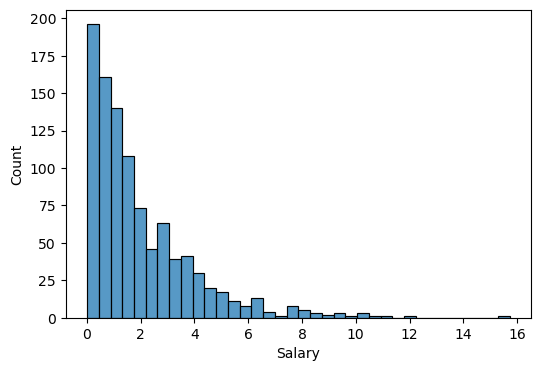

In [111]:
plt.figure(figsize=(6,4))
sns.histplot(df.Salary)
plt.show() #right skew

These bars we call it as a "Beans"
Beans =frquency of count
In the historgram it creates a beans based on the Range


In [112]:
df.Salary.skew()

1.9827754809935845

In [113]:
df["updated_Salary"], lambda_val=boxcox(df.Salary)

In [114]:
df.head()

,Salary,updated_Salary
0,1.644795,0.530701
1,0.166552,-1.437505
2,5.388234,2.105628
3,4.532809,1.845367
4,1.995917,0.756010


In [115]:
lambda_val

0.25599885761071717

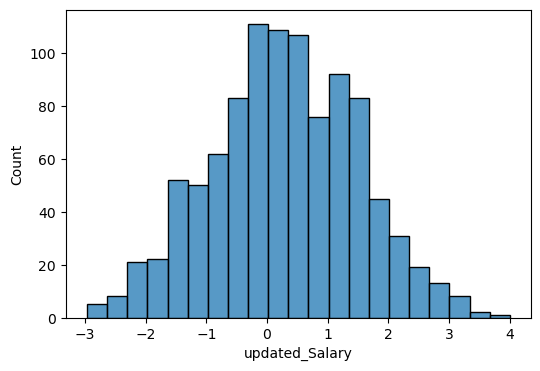

In [116]:
plt.figure(figsize=(6,4))
sns.histplot(df.updated_Salary)
plt.show() #Normal distribution

In [117]:
data=np.random.exponential(scale=2, size=1000)
data=10-data
df=pd.DataFrame({"Salary2":data})


In [118]:
df.head()

,Salary2
0,6.644901
1,5.811336
2,3.623095
3,8.865874
4,8.368213


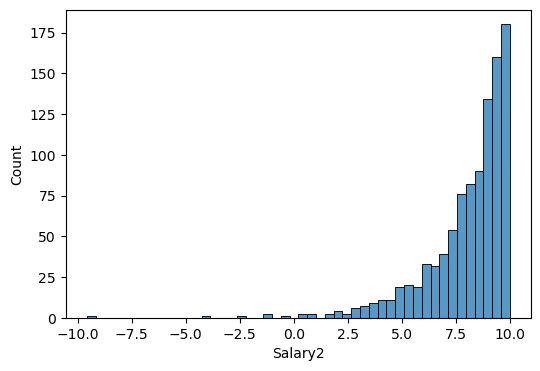

In [119]:
plt.figure(figsize=(6,4))
sns.histplot(df.Salary2)
plt.show()#left skew

In [120]:
df.Salary2.skew()

-2.376699687257588

In [121]:
df["reflex_salary"]=(df.Salary2.max()-df.Salary2)+1

In [122]:
df.head()

,Salary2,reflex_salary
0,6.644901,4.350392
1,5.811336,5.183957
2,3.623095,7.372198
3,8.865874,2.129419
4,8.368213,2.627080


In [123]:
df["transformed_salary"]=np.log(df.reflex_salary)+1

In [124]:
df.head()

,Salary2,reflex_salary,transformed_salary
0,6.644901,4.350392,2.470266
1,5.811336,5.183957,2.645569
2,3.623095,7.372198,2.997716
3,8.865874,2.129419,1.755849
4,8.368213,2.627080,1.965873


In [125]:
df.transformed_salary.skew()

0.45898034273172666

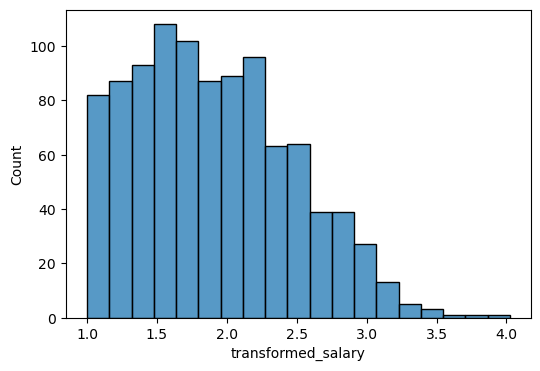

In [126]:
plt.figure(figsize=(6,4))
sns.histplot(df.transformed_salary)
plt.show()

In [127]:
df=pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\test2.csv")


In [128]:
df

,Unnamed: 0,Name,Age,Department,Salary
0,0,Alice,25.0,HR,50000.0
1,1,Bob,30.0,IT,60000.0
2,2,Charlie,35.0,Finance,70000.0
3,3,David,NaN,IT,62000.0
4,4,Eve,29.0,HR,NaN
5,5,Alice,25.0,HR,50000.0


In [129]:
df.shape

(6, 5)

In [130]:
df["Age"]=df["Age"].fillna(df["Age"].median())
df["Salary"]=df["Salary"].fillna(df["Salary"].median())

In [131]:
df

,Unnamed: 0,Name,Age,Department,Salary
0,0,Alice,25.0,HR,50000.0
1,1,Bob,30.0,IT,60000.0
2,2,Charlie,35.0,Finance,70000.0
3,3,David,29.0,IT,62000.0
4,4,Eve,29.0,HR,60000.0
5,5,Alice,25.0,HR,50000.0


In [132]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


In [133]:
df

,Unnamed: 0,Name,Age,Department,Salary
0,0,Alice,25.0,HR,50000.0
1,1,Bob,30.0,IT,60000.0
2,2,Charlie,35.0,Finance,70000.0
3,3,David,29.0,IT,62000.0
4,4,Eve,29.0,HR,60000.0
5,5,Alice,25.0,HR,50000.0


In [134]:
encoder=LabelEncoder()#labelencoder= convert the string value into the numerical values
onehotencoder also same

In [135]:
df["transformed_name"]=encoder.fit_transform(df.Name)

In [136]:
df.head()

,Unnamed: 0,Name,Age,Department,Salary,transformed_name
0,0,Alice,25.0,HR,50000.0,0
1,1,Bob,30.0,IT,60000.0,1
2,2,Charlie,35.0,Finance,70000.0,2
3,3,David,29.0,IT,62000.0,3
4,4,Eve,29.0,HR,60000.0,4


In [137]:
encoder2=OneHotEncoder(sparse_output=False)

In [139]:
encoded=encoder2.fit_transform(df[["Department"]])

In [140]:
encoder2.get_feature_names_out()

array(['Department_Finance', 'Department_HR', 'Department_IT'],
      dtype=object)

In [141]:
encoded 

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [143]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler   #for preprocessing steps

In [144]:
scaler=StandardScaler()

In [147]:
df["scaled_salary"]=scaler.fit_transform(df[["Salary"]])

In [148]:
df.head()

,Unnamed: 0,Name,Age,Department,Salary,transformed_name,scaled_salary
0,0,Alice,25.0,HR,50000.0,0,-1.239501
1,1,Bob,30.0,IT,60000.0,1,0.190693
2,2,Charlie,35.0,Finance,70000.0,2,1.620886
3,3,David,29.0,IT,62000.0,3,0.476731
4,4,Eve,29.0,HR,60000.0,4,0.190693


In [150]:
scaler=MinMaxScaler()

In [151]:
df["scaled_salary"]=scaler.fit_transform(df[["Salary"]])

In [152]:
df.head()

,Unnamed: 0,Name,Age,Department,Salary,transformed_name,scaled_salary
0,0,Alice,25.0,HR,50000.0,0,0.0
1,1,Bob,30.0,IT,60000.0,1,0.5
2,2,Charlie,35.0,Finance,70000.0,2,1.0
3,3,David,29.0,IT,62000.0,3,0.6
4,4,Eve,29.0,HR,60000.0,4,0.5


In [2]:
import pandas as pd
data=pd.read_csv(r"C:\Users\Lenovo\Downloads\data_visualization.csv")

In [3]:
data

,Unnamed: 0,Student_ID,Name,Gender,Department,Age,Math_Score,Science_Score,Attendance_Percentage,Study_Hours_per_Week
0,0,1,Aarav,Male,CS,21,78,75,85,10
1,1,2,Diya,Female,IT,22,85,88,90,12
2,2,3,Rohan,Male,CS,20,90,85,95,15
3,3,4,Sneha,Female,ECE,21,67,70,80,8
4,4,5,Arjun,Male,IT,23,88,90,92,14
5,5,6,Meera,Female,ECE,22,76,79,88,9
6,6,7,Kiran,Male,CS,21,92,94,96,16
7,7,8,Ananya,Female,IT,20,81,83,89,11
8,8,9,Rahul,Male,ECE,22,74,72,75,7
9,9,10,Isha,Female,CS,23,89,91,93,15


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

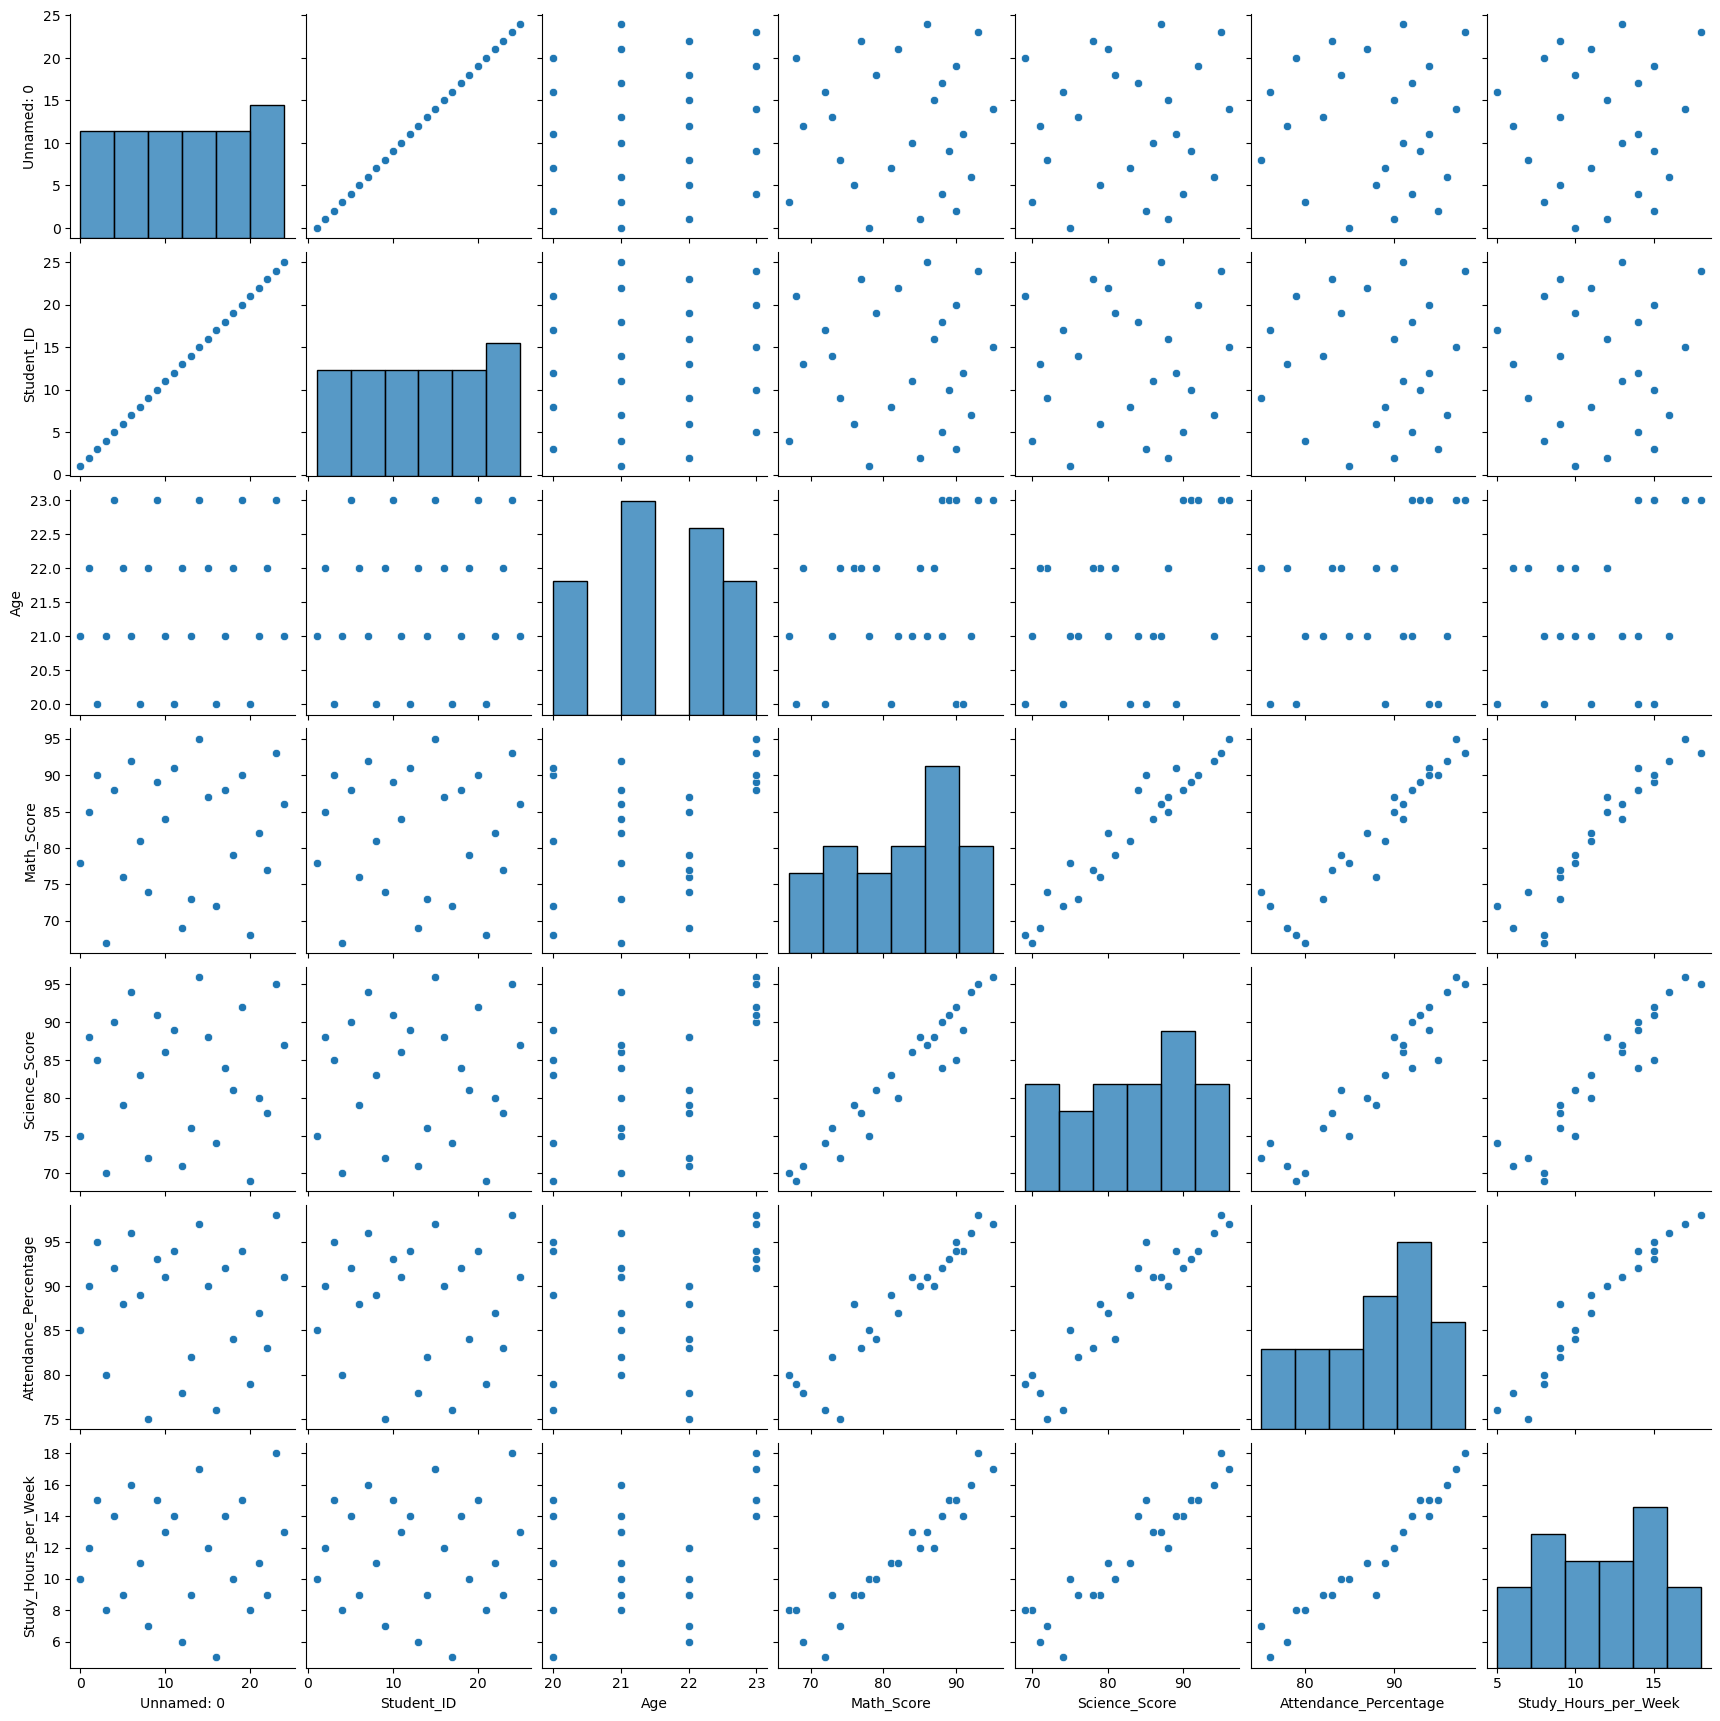

In [6]:
sns.pairplot(data)

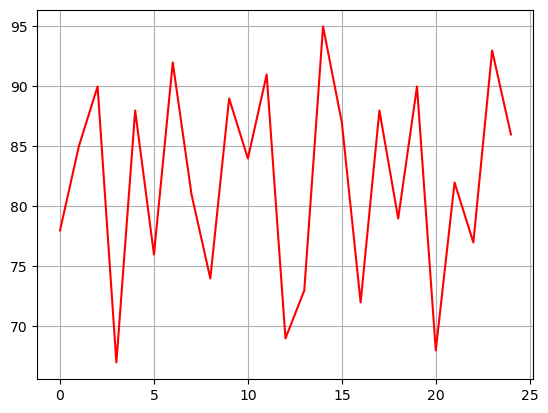

In [7]:
plt.plot(data.Math_Score, color="red")
plt.grid()
plt.show()

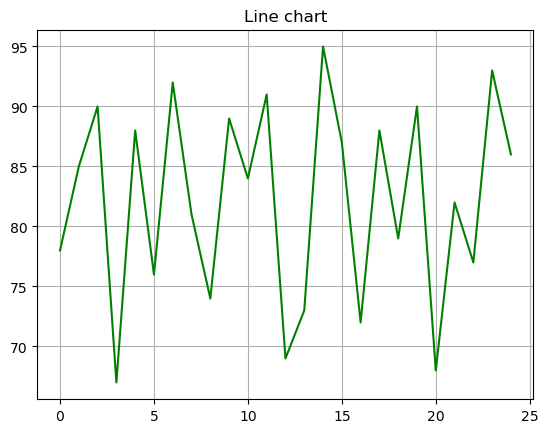

In [8]:
plt.plot(data.Math_Score, color="green")
plt.grid()
plt.title("Line chart")
plt.show()

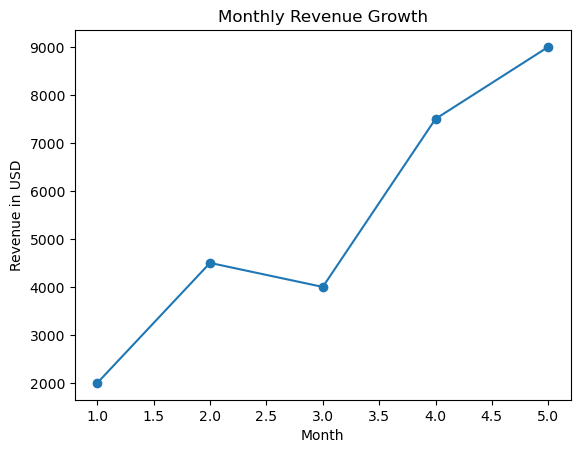

In [10]:
import matplotlib.pyplot as plt

# Data
months = [1, 2, 3, 4, 5]
revenue = [2000, 4500, 4000, 7500, 9000]

# Line plot
plt.plot(months, revenue, marker='o')

# Title and labels
plt.title("Monthly Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Revenue in USD")

# Show plot
plt.show()

Why line plots are essential

Line plots make it easy to see trends, patterns, and changes over time. When data is in a natural order (like days, months, or years), our eyes can quickly follow the line to understand:

Trends – whether values are increasing, decreasing, or staying steady Slopes – how fast something is growing or falling

Fluctuations – ups and downs that are hard to notice in tables

Time-based patterns – cycles, spikes, or drops

Compared to reading a table of numbers, a line plot lets you understand the story of the data at a glance, making it one of the most powerful tools for visualizing continuous data